### Double-knob designs
Run the cells top to bottom. Edit the `👈` value and re-run.

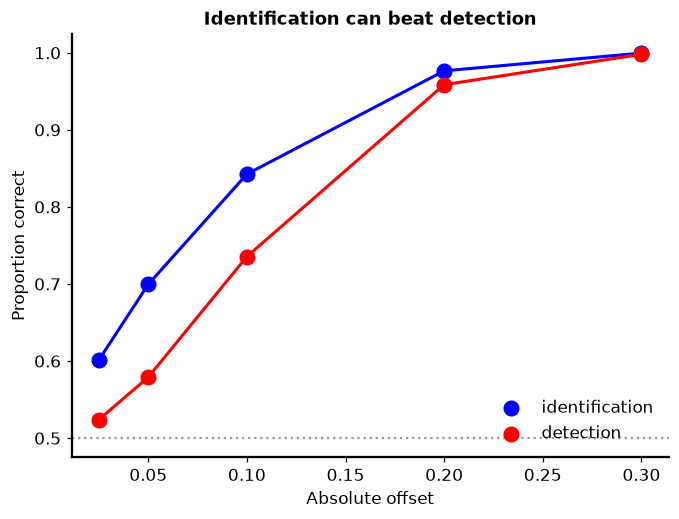

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# A "double-knob" task: each trial, detect WHICH interval held the offset,
# and identify whether the offset was leftward or rightward.
signal_strengths = np.array([-0.3,-0.2,-0.1,-0.05,-0.025,0.025,0.05,0.1,0.2,0.3])
noise_sd = 0.07     # 👈 internal noise
ntrials  = 1000
rng = np.random.default_rng(); half = ntrials // 2

first  = rng.standard_normal((ntrials, signal_strengths.size)) * noise_sd
second = rng.standard_normal((ntrials, signal_strengths.size)) * noise_sd
first[:half]  += signal_strengths   # first half of trials: offset is in interval 1
second[half:] += signal_strengths   # second half: offset is in interval 2

# detection: respond "second" if the offset felt larger in interval 2
detect   = (np.abs(second) - np.abs(first)) > 0
# identification: respond "right" if the overall offset is rightward (positive)
identify = (first + second) > 0

pright  = np.column_stack([identify[:half].mean(0), identify[half:].mean(0)])
psecond = np.column_stack([detect[:half].mean(0),   detect[half:].mean(0)])
pright_full = pright.mean(axis=1)

abs_devs = np.unique(np.abs(signal_strengths))
pc_detect, pc_ident = [], []
for d in abs_devs:
    m = np.isclose(np.abs(signal_strengths), d)
    pc_detect.append(np.mean((psecond[m, 1] + (1 - psecond[m, 0])) / 2))
    i_neg = np.isclose(signal_strengths, -d); i_pos = np.isclose(signal_strengths, d)
    pc_ident.append(((1 - pright_full[i_neg][0]) + pright_full[i_pos][0]) / 2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(abs_devs, pc_ident, "b", lw=2); ax.scatter(abs_devs, pc_ident, 90, color="b", zorder=3, label="identification")
ax.plot(abs_devs, pc_detect, "r", lw=2); ax.scatter(abs_devs, pc_detect, 90, color="r", zorder=3, label="detection")
ax.axhline(0.5, color="0.6", ls=":")
ax.set(xlabel="Absolute offset", ylabel="Proportion correct",
       title="Identification can beat detection")
ax.legend(loc="lower right")
plt.show()


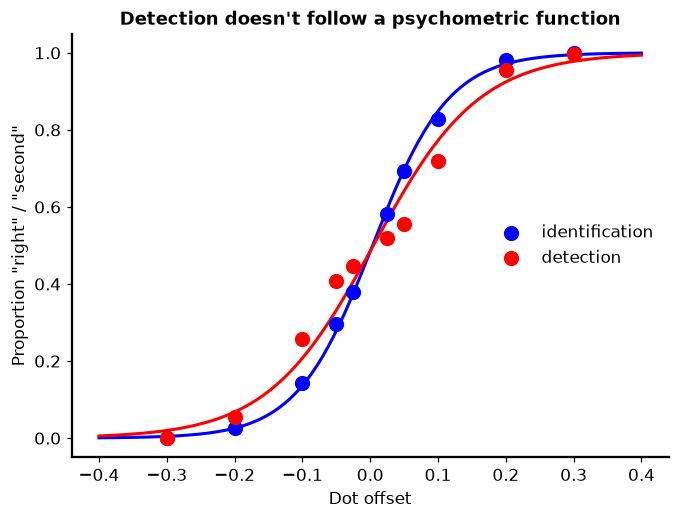

In [2]:
# fit logistic psychometric functions to detection and identification
def logistic_pf(p, x):
    return 1.0 / (1.0 + np.exp(-p[1] * (x - p[0])))

def neg_log_lik(p, pf, x, n_right, n_total):
    pp = np.clip(pf(p, x), 1e-6, 1 - 1e-6)
    return -np.sum(n_right * np.log(pp) + (n_total - n_right) * np.log(1 - pp))

# the "full" detection curve: for negative offsets use interval-1 trials, etc.
psecond_full = np.empty(signal_strengths.size)
nhalf = signal_strengths.size // 2
psecond_full[:nhalf] = psecond[:nhalf, 0]
psecond_full[nhalf:] = psecond[nhalf:, 1]

nt = np.full(signal_strengths.size, half)
fit_i = minimize(lambda p: neg_log_lik(p, logistic_pf, signal_strengths, pright_full*half, nt),
                 x0=[0, 10], method="Nelder-Mead").x
fit_d = minimize(lambda p: neg_log_lik(p, logistic_pf, signal_strengths, psecond_full*half, nt),
                 x0=[0, 10], method="Nelder-Mead").x

xs = np.linspace(-0.4, 0.4, 200)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xs, logistic_pf(fit_i, xs), "b", lw=2)
ax.plot(xs, logistic_pf(fit_d, xs), "r", lw=2)
ax.scatter(signal_strengths, pright_full, 80, color="b", zorder=3, label="identification")
ax.scatter(signal_strengths, psecond_full, 80, color="r", zorder=3, label="detection")
ax.set(xlabel="Dot offset", ylabel='Proportion "right" / "second"',
       title="Detection doesn't follow a psychometric function")
ax.legend(loc="center right")
plt.show()


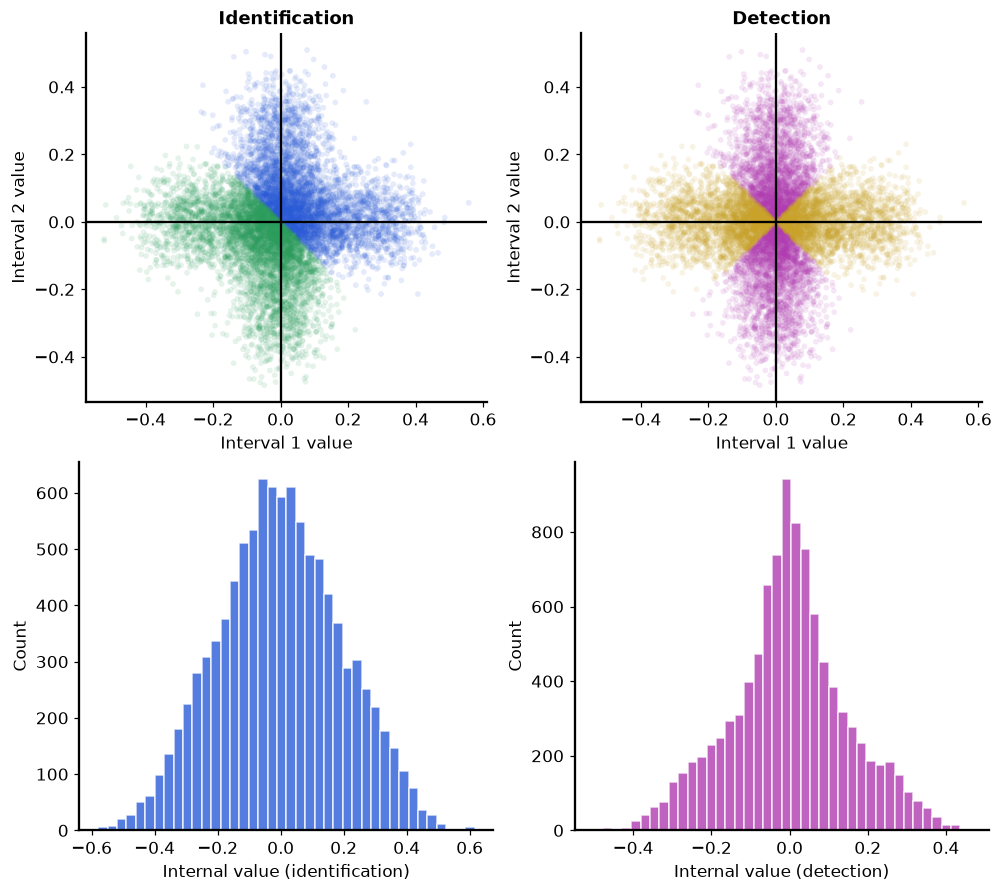

In [3]:
# why? look at the evidence and the decision rules
fig, axs = plt.subplots(2, 2, figsize=(9, 8), constrained_layout=True)

internal_identify = first + second
internal_detect   = np.abs(second) - np.abs(first)

# identification: a straight diagonal boundary in (interval1, interval2) space
ax = axs[0, 0]
ax.scatter(first[identify], second[identify], 14, color="#2a5bd7", alpha=0.12, edgecolors="none")
ax.scatter(first[~identify], second[~identify], 14, color="#2a9d5c", alpha=0.12, edgecolors="none")
ax.axhline(0, color="k", lw=1.5); ax.axvline(0, color="k", lw=1.5)
ax.set(xlabel="Interval 1 value", ylabel="Interval 2 value", title="Identification"); ax.set_aspect("equal")

axs[1, 0].hist(internal_identify.ravel(), bins=40, color="#2a5bd7", alpha=0.8, edgecolor="white")
axs[1, 0].set(xlabel="Internal value (identification)", ylabel="Count")

# detection: a non-linear (corner-shaped) boundary -> bimodal evidence
ax = axs[0, 1]
ax.scatter(first[detect], second[detect], 14, color="#b13bb1", alpha=0.12, edgecolors="none")
ax.scatter(first[~detect], second[~detect], 14, color="#c9a227", alpha=0.12, edgecolors="none")
ax.axhline(0, color="k", lw=1.5); ax.axvline(0, color="k", lw=1.5)
ax.set(xlabel="Interval 1 value", ylabel="Interval 2 value", title="Detection"); ax.set_aspect("equal")

axs[1, 1].hist(internal_detect.ravel(), bins=40, color="#b13bb1", alpha=0.8, edgecolor="white")
axs[1, 1].set(xlabel="Internal value (detection)", ylabel="Count")
plt.show()
